In [2]:
import os
import pandas as pd
from datasets import load_dataset
import json
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import glob

/home/jcuello/miniforge3/envs/emo_drift_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# ShareGPT_92k

In [ ]:
# Skip if done once and files are already downloaded, raises an error
df = load_dataset("RyokoAI/ShareGPT52K")

df.head()

In [4]:
df1 = pd.read_json("/home/jcuello/.cache/huggingface/hub/datasets--RyokoAI--ShareGPT52K/snapshots/6f9b78cc1dd15dbb51d3c51ccc219c558962fd77/sg_90k_part1.json")
df2 = pd.read_json("/home/jcuello/.cache/huggingface/hub/datasets--RyokoAI--ShareGPT52K/snapshots/6f9b78cc1dd15dbb51d3c51ccc219c558962fd77/sg_90k_part2.json")

print(df1.head())
print(df2.head())

        id                                      conversations
0  Og9h3C1  [{'from': 'human', 'value': 'root@openvpn:/hom...
1  QWJhYvA  [{'from': 'human', 'value': 'Summarize the mai...
2  zi8VbDz  [{'from': 'human', 'value': '提供一個媒體招待會的流程表，內容是...
3  i6IyJda  [{'from': 'human', 'value': 'How to tell if a ...
4  A5AbcES  [{'from': 'human', 'value': 'In Java, I want t...
        id                                      conversations
0  RzBNjvK  [{'from': 'human', 'value': 'Answer as if you ...
1  Hhq5zTB  [{'from': 'human', 'value': 'Web search result...
2  WH9pL3D  [{'from': 'human', 'value': 'Web search result...
3  KTIJQ1O  [{'from': 'human', 'value': 'Write a python se...
4  GZ9llsx  [{'from': 'human', 'value': '1 / 1- Prompts # ...


In [5]:
df_sharegpt = pd.concat([df1, df2], ignore_index=True)

df_sharegpt.shape

(90665, 2)

In [13]:
for conv in df_sharegpt["conversations"].head():
    print(conv)
    print(type(conv))
    print(len(conv))

type(df_sharegpt["conversations"].iloc[0][0])

[{'from': 'human', 'value': "root@openvpn:/home/openvpn# ./openvpn-install.sh\nWelcome to OpenVPN-install!\nThe git repository is available at: https://github.com/angristan/openvpn-install\n\nIt looks like OpenVPN is already installed.\n\nWhat do you want to do?\n   1) Add a new user\n   2) Revoke existing user\n   3) Remove OpenVPN\n   4) Exit\nSelect an option [1-4]: 1\n\nTell me a name for the client.\nThe name must consist of alphanumeric character. It may also include an underscore or a dash.\nClient name: naam\n\nDo you want to protect the configuration file with a password?\n(e.g. encrypt the private key with a password)\n   1) Add a passwordless client\n   2) Use a password for the client\nSelect an option [1-2]: 1\n\nNote: using Easy-RSA configuration from: /etc/openvpn/easy-rsa/vars\nUsing SSL: openssl OpenSSL 3.0.2 15 Mar 2022 (Library: OpenSSL 3.0.2 15 Mar 2022)\n-----\nUsing configuration from /etc/openvpn/easy-rsa/pki/easy-rsa-54848.BT2FXv/tmp.dFLd6V\nEnter pass phrase fo

dict

Each value of the column "conversations" is a list, which contains dicts for the utterances of the conversation (len(conv) = num_utterances).

In [15]:
df_sharegpt.to_csv("/home/jcuello/emotion_drift/data/01_stimuli/sharegpt/sharegpt_92k.csv")

# GoEmotions

In [16]:
df1 = pd.read_csv("/home/jcuello/emotion_drift/data/01_stimuli/goemotions/goemotions_1.csv")
df2 = pd.read_csv("/home/jcuello/emotion_drift/data/01_stimuli/goemotions/goemotions_2.csv")
df3 = pd.read_csv("/home/jcuello/emotion_drift/data/01_stimuli/goemotions/goemotions_3.csv")

df_goemotions = pd.concat([df1,df2,df3], ignore_index=True)

df_goemotions.head()

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1


In [19]:
print(len(df_goemotions.link_id.unique()))
print(len(df_goemotions.parent_id.unique()))
print(df_goemotions.shape)

44897
54924
(211225, 37)


In [20]:
df_goemotions.columns

Index(['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id',
       'created_utc', 'rater_id', 'example_very_unclear', 'admiration',
       'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion',
       'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust',
       'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy',
       'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
       'remorse', 'sadness', 'surprise', 'neutral'],
      dtype='object')

In [22]:
clear_examples = df_goemotions[df_goemotions["example_very_unclear"]==0]

len(clear_examples)

207814

/tmp/ipykernel_1175718/3066607807.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=conteos_emociones.index, y=conteos_emociones.values, palette='viridis')


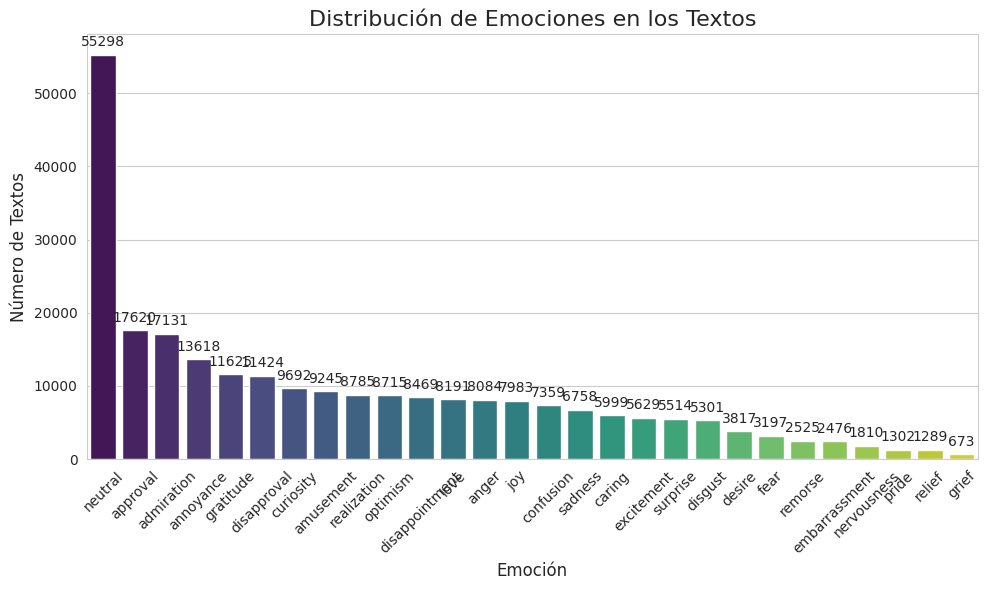

In [26]:
columnas_emociones = ['admiration',
       'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion',
       'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust',
       'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy',
       'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
       'remorse', 'sadness', 'surprise', 'neutral']

conteos_emociones = clear_examples[columnas_emociones].sum()

conteos_emociones = conteos_emociones.sort_values(ascending=False)

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6)) 

barplot = sns.barplot(x=conteos_emociones.index, y=conteos_emociones.values, palette='viridis')

# Añade etiquetas y título
plt.title('Distribución de Emociones en los Textos', fontsize=16)
plt.ylabel('Número de Textos', fontsize=12)
plt.xlabel('Emoción', fontsize=12)

plt.xticks(rotation=45)

for p in barplot.patches:
    barplot.annotate(f'{int(p.get_height())}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1175718/1742129069.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clear_examples['num_emociones'] = clear_examples[columnas_emociones].sum(axis=1)
/tmp/ipykernel_1175718/1742129069.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=conteo_num_emociones.index, y=conteo_num_emociones.values, palette='rocket')


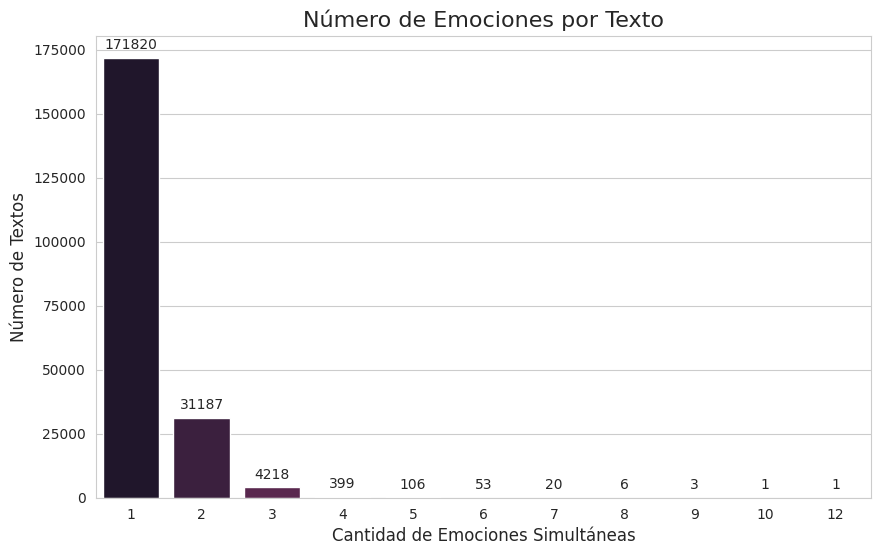

In [27]:
clear_examples['num_emociones'] = clear_examples[columnas_emociones].sum(axis=1)

conteo_num_emociones = clear_examples['num_emociones'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
barplot = sns.barplot(x=conteo_num_emociones.index, y=conteo_num_emociones.values, palette='rocket')

plt.title('Número de Emociones por Texto', fontsize=16)
plt.xlabel('Cantidad de Emociones Simultáneas', fontsize=12)
plt.ylabel('Número de Textos', fontsize=12)

for p in barplot.patches:
    barplot.annotate(f'{int(p.get_height())}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 9),
                   textcoords='offset points')

plt.show()

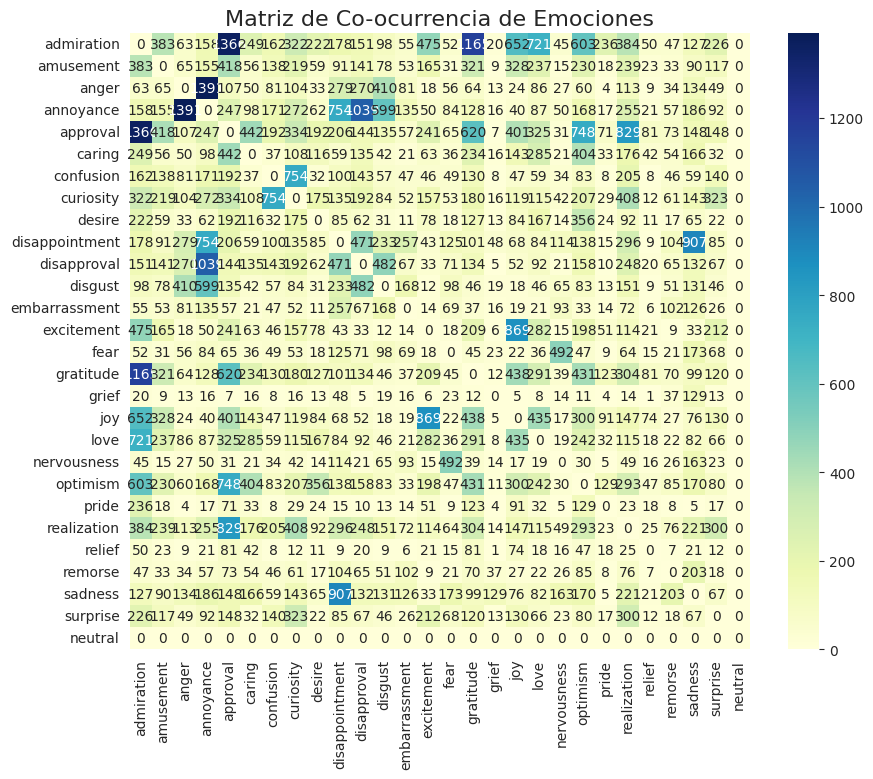

In [28]:
df_emociones = clear_examples[columnas_emociones]

matriz_coocurrencia = df_emociones.T.dot(df_emociones)

for i in range(len(matriz_coocurrencia)):
    matriz_coocurrencia.iloc[i, i] = 0

# Graficar el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_coocurrencia, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Matriz de Co-ocurrencia de Emociones', fontsize=16)
plt.show()

In [41]:
very_emotional_samples = clear_examples[clear_examples["num_emociones"] >= 9]

for i, very_emotional_text in very_emotional_samples.iterrows():
    print(very_emotional_text.text)
    print([emotion for emotion in clear_examples.columns if very_emotional_text[emotion]==1])

American democracy is weak but it's not dead. If the intention of your comment was to discourage people from voting then you are the problem.
['annoyance', 'disappointment', 'disgust', 'embarrassment', 'grief', 'nervousness', 'optimism', 'realization', 'sadness']
Despite how much the Liberals and NDP apparently hate each other they really do work well together.
['admiration', 'anger', 'caring', 'confusion', 'desire', 'disgust', 'embarrassment', 'nervousness', 'sadness']
Sadly, he seems immune to bans. He also dodges them with alts like [NAME]
['admiration', 'anger', 'caring', 'desire', 'disappointment', 'disgust', 'embarrassment', 'relief', 'sadness']
At least you should have helped out since you had rudely interrupted him.
['admiration', 'anger', 'caring', 'curiosity', 'disgust', 'embarrassment', 'nervousness', 'realization', 'remorse', 'sadness']
Two or three anti depressants before I told them a lie about how I tried my moms valium and it worked
['admiration', 'approval', 'curiosity

It seems like some data-points are over-annotated. For example, how can an emotional experience be 'embarrassment', 'fear', 'gratitude', 'nervousness', 'optimism', 'pride' at the same time? They're all very different emotions, and imagine it is possible, it's not observable in a 20 word reddit post.

INSIGHT: If we use this dataset, some over-annotated examples should be discarded.

In [ ]:
clear_examples.to_csve("/home/jcuello/emotion_drift/data/01_stimuli/goemotions/goemotions_clear_examples.csv")

# DailyDialog

In [3]:
zip_file_path_test = "/home/jcuello/emotion_drift/data/01_stimuli/dailydialogues/test.zip"
with zipfile.ZipFile(zip_file_path_test, 'r') as zip_ref:
    print("Files in the zip archive:")
    
    zip_ref.printdir()

    print("\nGetting file names as a list:")
    
    file_list = zip_ref.namelist()
    print(file_list)

zip_file_path_train = "/home/jcuello/emotion_drift/data/01_stimuli/dailydialogues/train.zip"
with zipfile.ZipFile(zip_file_path_test, 'r') as zip_ref:
    print("Files in the zip archive:")
    
    zip_ref.printdir()

    print("\nGetting file names as a list:")
    
    file_list = zip_ref.namelist()
    print(file_list)

zip_file_path_validation = "/home/jcuello/emotion_drift/data/01_stimuli/dailydialogues/validation.zip"
with zipfile.ZipFile(zip_file_path_test, 'r') as zip_ref:
    print("Files in the zip archive:")
    
    zip_ref.printdir()

    print("\nGetting file names as a list:")
    
    file_list = zip_ref.namelist()
    print(file_list)

Files in the zip archive:
File Name                                             Modified             Size
test/                                          2017-04-15 03:56:06            0
test/dialogues_act_test.txt                    2017-04-15 03:53:34        16480
test/dialogues_emotion_test.txt                2017-04-15 03:54:08        16480
test/dialogues_test.txt                        2017-04-15 03:49:04       544208

Getting file names as a list:
['test/', 'test/dialogues_act_test.txt', 'test/dialogues_emotion_test.txt', 'test/dialogues_test.txt']
Files in the zip archive:
File Name                                             Modified             Size
test/                                          2017-04-15 03:56:06            0
test/dialogues_act_test.txt                    2017-04-15 03:53:34        16480
test/dialogues_emotion_test.txt                2017-04-15 03:54:08        16480
test/dialogues_test.txt                        2017-04-15 03:49:04       544208

Getting file 

In [4]:
extract_to_dir = "/home/jcuello/emotion_drift/data/01_stimuli/dailydialogues"

with zipfile.ZipFile(zip_file_path_test, 'r') as zip_ref:
    print(f"Extracting all files to '{extract_to_dir}'...")
    # Extract all the contents of the zip file into the specified directory
    zip_ref.extractall(extract_to_dir)
    print("Extraction complete.")

with zipfile.ZipFile(zip_file_path_train, 'r') as zip_ref:
    print(f"Extracting all files to '{extract_to_dir}'...")
    # Extract all the contents of the zip file into the specified directory
    zip_ref.extractall(extract_to_dir)
    print("Extraction complete.")

with zipfile.ZipFile(zip_file_path_validation, 'r') as zip_ref:
    print(f"Extracting all files to '{extract_to_dir}'...")
    # Extract all the contents of the zip file into the specified directory
    zip_ref.extractall(extract_to_dir)
    print("Extraction complete.")

Extracting all files to '/home/jcuello/emotion_drift/data/01_stimuli/dailydialogues'...
Extraction complete.
Extracting all files to '/home/jcuello/emotion_drift/data/01_stimuli/dailydialogues'...
Extraction complete.
Extracting all files to '/home/jcuello/emotion_drift/data/01_stimuli/dailydialogues'...
Extraction complete.


In [5]:
lista_dfs_por_set = []

for set_name in ["train", "validation", "test"]:
    folder_path = os.path.join(extract_to_dir, set_name)
    print(f"--- Procesando el set: {set_name} ---")

    file_list = glob.glob(os.path.join(folder_path, "*.txt"))

    # Lista para las columnas de ESTE set
    columnas_del_set = []
    for file_path in file_list:
        column_name = os.path.basename(file_path).replace('.txt', '')
        
        # Leemos cada archivo como una única columna
        series = pd.read_csv(file_path, header=None, delimiter='\t', quoting=3).iloc[:, 0]
        series.name = column_name
        columnas_del_set.append(series)

    if columnas_del_set:
        set_df = pd.concat(columnas_del_set, axis=1)
        
        # Añadimos una columna para identificar de dónde vienen estos datos
        set_df['set'] = set_name
        
        # Guardamos el DataFrame completo de este set en nuestra lista principal
        lista_dfs_por_set.append(set_df)

--- Procesando el set: train ---
--- Procesando el set: validation ---
--- Procesando el set: test ---


In [25]:
lista_dfs_por_set[0]

,dialogues_emotion_train,dialogues_act_train,dialogues_train,set
0,0 0 0 0 0 0 4 4 4 4,3 4 2 2 2 3 4 1 3 4,"Say , Jim , how about going for a few beers af...",train
1,0 0 6 0 0 0,2 1 2 2 1 1,Can you do push-ups ? __eou__ Of course I can ...,train
2,0 0 0 0 0,2 1 2 1 1,"Can you study with the radio on ? __eou__ No ,...",train
3,0 0 0 0,2 1 1 1,Are you all right ? __eou__ I will be all righ...,train
4,0 0 0 0 0 6 0 6 0,2 1 2 1 1 2 1 3 4,"Hey John , nice skates . Are they new ? __eou_...",train
...,...,...,...,...
11113,0 4 0 0 0 0 0 0 4,1 1 1 2 3 2 1 4 1,"Hello , I bought a pen in your shop just befor...",train
11114,0 0 0 0 0 4,2 1 2 1 3 4,Do you have any seats available ? __eou__ Yes ...,train
11115,0 0 6 0 6 0 0 0 0 0 0 0 0 0 4 0,2 1 2 1 1 1 1 1 2 1 2 1 2 1 3 4,"Uncle Ben , how did the Forbidden City get thi...",train
11116,0 0 0 0,2 3 4 3,"May I help you , sir ? __eou__ I want a pair o...",train


In [23]:
organized_dfs_list = []
for i in range(len(lista_dfs_por_set)):
    df = lista_dfs_por_set[i]
    if i == 0:
        set = 'train'
    elif i == 1:
        set = 'validation'
    else:
        print(i)
        set = 'test'

    new_rows = []
    
    for index, row in df.iterrows():
        # Split the columns into lists
        # Use .split() with no arguments to handle any whitespace and remove empty strings
        emotions = row[f'dialogues_emotion_{set}'].split() # <-- CHANGED LINE
        acts = row[f'dialogues_act_{set}'].split()         # <-- CHANGED LINE
        utterances = row[f'dialogues_{set}'].split('__eou__')

        # Use zip to combine the lists element-wise
        # zip automatically stops when the shortest list is exhausted, which handles
        # cases where the number of items might not perfectly match.
        for utterance, emotion, act in zip(utterances, emotions, acts):
            new_rows.append({
                'dialogue_id': index,
                'utterance': utterance.strip(),
                'emotion': int(emotion),
                'act': int(act),
                'set': row['set']
            })

    # 3. Create the new, organized DataFrame
    organized_df = pd.DataFrame(new_rows)
    organized_dfs_list.append(organized_df)
    # Display the first few rows of the new DataFrame
    print(organized_df.head(15))

daily_dialog_df = pd.concat(organized_dfs_list)

daily_dialog_df.head()


    dialogue_id                                          utterance  emotion  \
0             0  Say , Jim , how about going for a few beers af...        0   
1             0  You know that is tempting but is really not go...        0   
2             0      What do you mean ? It will help us to relax .        0   
3             0  Do you really think so ? I don't . It will jus...        0   
4             0  I guess you are right.But what shall we do ? I...        0   
5             0  I suggest a walk over to the gym where we can ...        0   
6             0  That's a good idea . I hear Mary and Sally oft...        4   
7             0  Sounds great to me ! If they are willing , we ...        4   
8             0                              Good.Let ' s go now .        4   
9             0                                        All right .        4   
10            1                              Can you do push-ups ?        0   
11            1  Of course I can . It's a piece of c

,dialogue_id,utterance,emotion,act,set
0,0,"Say , Jim , how about going for a few beers af...",0,3,train
1,0,You know that is tempting but is really not go...,0,4,train
2,0,What do you mean ? It will help us to relax .,0,2,train
3,0,Do you really think so ? I don't . It will jus...,0,2,train
4,0,I guess you are right.But what shall we do ? I...,0,2,train


In [24]:
print(daily_dialog_df)

      dialogue_id                                          utterance  emotion  \
0               0  Say , Jim , how about going for a few beers af...        0   
1               0  You know that is tempting but is really not go...        0   
2               0      What do you mean ? It will help us to relax .        0   
3               0  Do you really think so ? I don't . It will jus...        0   
4               0  I guess you are right.But what shall we do ? I...        0   
...           ...                                                ...      ...   
7735          999  are you kidding ? Can you afford it ? Do you t...        6   
7736          999  never mind that , I'll take care of it . Are y...        0   
7737          999                                yeah , I think so .        0   
7738          999  ok . I'll make the arrangements . It will be g...        4   
7739          999     wonderful ! I'll start packing our suitcases .        4   

      act    set  
0       

In [26]:
daily_dialog_df.emotion.unique()

array([0, 4, 6, 3, 2, 5, 1])

In [28]:
daily_dialog_df.emotion.value_counts()

emotion
0    85572
4    12885
6     1823
5     1150
1     1022
2      353
3      174
Name: count, dtype: int64

The mapping is done based on the value_counts of the original paper (http://yanran.li/files/ijcnlp2017dailydialog.pdf).

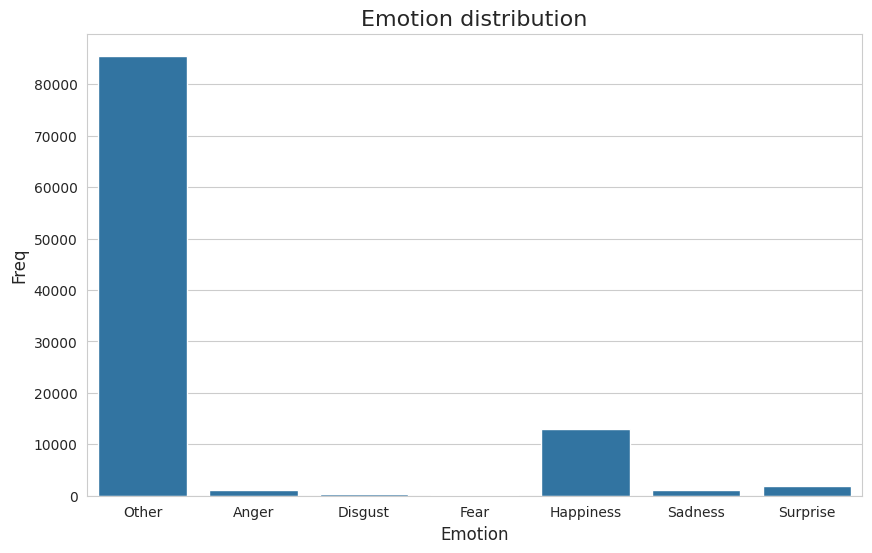

In [30]:
emotion_map = {
    0: 'Other',
    1: 'Anger',
    2: 'Disgust',
    3: 'Fear',
    4: 'Happiness',
    5: 'Sadness',
    6: 'Surprise'
}

daily_dialog_df['emotion_label'] = daily_dialog_df['emotion'].map(emotion_map)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

plot = sns.countplot(
    x='emotion_label',
    data=daily_dialog_df,
    order=emotion_map.values()
)

plot.set_title('Emotion distribution', fontsize=16)
plot.set_xlabel('Emotion', fontsize=12)
plot.set_ylabel('Freq', fontsize=12)

plt.show()

Most of the labels are "Other", which gives 0 information (in the paper the authors state that the Ekman's 6 was not enough to describe the dataset utterances, but that it was the most used so they would use it anyways)

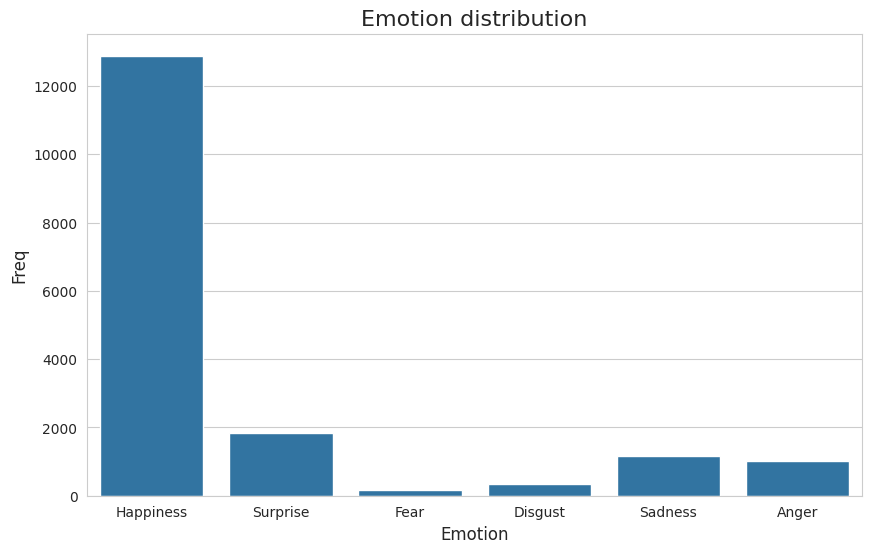

In [33]:
subset_wo_other = daily_dialog_df[daily_dialog_df["emotion_label"]!="Other"]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

plot = sns.countplot(
    x='emotion_label',
    data=subset_wo_other,
)

plot.set_title('Emotion distribution', fontsize=16)
plot.set_xlabel('Emotion', fontsize=12)
plot.set_ylabel('Freq', fontsize=12)

plt.show()

Huge bias towards happiness (makes sense, since it's the only positive emotion in the framework). 

In [34]:
daily_dialog_df.to_csv("/home/jcuello/emotion_drift/data/01_stimuli/dailydialogues/daily_dialog.csv")

# LoCoMo

In [38]:
locomo_df = pd.read_json("/home/jcuello/emotion_drift/data/01_stimuli/locomo/locomo10.json")

In [40]:
print(locomo_df.shape)

locomo_df.head()

(10, 6)


,qa,conversation,event_summary,observation,session_summary,sample_id
0,[{'question': 'When did Caroline go to the LGB...,"{'speaker_a': 'Caroline', 'speaker_b': 'Melani...",{'events_session_1': {'Caroline': ['Caroline a...,{'session_1_observation': {'Caroline': [['Caro...,{'session_1_summary': 'Caroline and Melanie ha...,conv-26
1,[{'question': 'When Jon has lost his job as a ...,"{'speaker_a': 'Jon', 'speaker_b': 'Gina', 'ses...",{'events_session_1': {'Jon': ['Jon loses his j...,{'session_1_observation': {'Gina': [['Gina los...,{'session_1_summary': 'Gina and Jon met at 4:0...,conv-30
2,[{'question': 'Who did Maria have dinner with ...,"{'speaker_a': 'John', 'speaker_b': 'Maria', 's...","{'events_session_1': {'John': ['John, his wife...",{'session_1_observation': {'Maria': [['Maria v...,{'session_1_summary': 'Maria and John met at 1...,conv-41
3,[{'question': 'Is it likely that Nate has frie...,"{'speaker_a': 'Joanna', 'speaker_b': 'Nate', '...","{'events_session_1': {'Joanna': [], 'Nate': ['...",{'session_1_observation': {'Nate': [['Nate won...,{'session_1_summary': 'Nate and Joanna caught ...,conv-42
4,[{'question': 'what are John's goals with rega...,"{'speaker_a': 'Tim', 'speaker_b': 'John', 'ses...",{'events_session_1': {'Tim': ['Tim contacts hi...,{'session_1_observation': {'John': [['John sig...,{'session_1_summary': 'John and Tim had a conv...,conv-43


In [44]:
locomo_df.iloc[0].event_summary.keys()

dict_keys(['events_session_1', 'events_session_2', 'events_session_3', 'events_session_4', 'events_session_5', 'events_session_6', 'events_session_7', 'events_session_8', 'events_session_9', 'events_session_10', 'events_session_11', 'events_session_12', 'events_session_13', 'events_session_14', 'events_session_15', 'events_session_16', 'events_session_17', 'events_session_18', 'events_session_19'])

In [46]:
locomo_df.iloc[0].event_summary["events_session_1"]

{'Caroline': ['Caroline attends an LGBTQ support group for the first time.'],
 'Melanie': [],
 'date': '8 May, 2023'}

In [48]:
locomo_df.iloc[0].conversation.keys()

dict_keys(['speaker_a', 'speaker_b', 'session_1_date_time', 'session_1', 'session_2_date_time', 'session_2', 'session_3_date_time', 'session_3', 'session_4_date_time', 'session_4', 'session_5_date_time', 'session_5', 'session_6_date_time', 'session_6', 'session_7_date_time', 'session_7', 'session_8_date_time', 'session_8', 'session_9_date_time', 'session_9', 'session_10_date_time', 'session_10', 'session_11_date_time', 'session_11', 'session_12_date_time', 'session_12', 'session_13_date_time', 'session_13', 'session_14_date_time', 'session_14', 'session_15_date_time', 'session_15', 'session_16_date_time', 'session_16', 'session_17_date_time', 'session_17', 'session_18_date_time', 'session_18', 'session_19_date_time', 'session_19', 'session_20_date_time', 'session_21_date_time', 'session_22_date_time', 'session_23_date_time', 'session_24_date_time', 'session_25_date_time', 'session_26_date_time', 'session_27_date_time', 'session_28_date_time', 'session_29_date_time', 'session_30_date_ti

In [50]:
locomo_df.iloc[0].conversation["session_1"]

[{'speaker': 'Caroline',
  'dia_id': 'D1:1',
  'text': 'Hey Mel! Good to see you! How have you been?'},
 {'speaker': 'Melanie',
  'dia_id': 'D1:2',
  'text': "Hey Caroline! Good to see you! I'm swamped with the kids & work. What's up with you? Anything new?"},
 {'speaker': 'Caroline',
  'dia_id': 'D1:3',
  'text': 'I went to a LGBTQ support group yesterday and it was so powerful.'},
 {'speaker': 'Melanie',
  'dia_id': 'D1:4',
  'text': "Wow, that's cool, Caroline! What happened that was so awesome? Did you hear any inspiring stories?"},
 {'speaker': 'Caroline',
  'img_url': ['https://i.redd.it/l7hozpetnhlb1.jpg'],
  'blip_caption': 'a photo of a dog walking past a wall with a painting of a woman',
  'query': 'transgender pride flag mural',
  'dia_id': 'D1:5',
  'text': 'The transgender stories were so inspiring! I was so happy and thankful for all the support.'},
 {'speaker': 'Melanie',
  'dia_id': 'D1:6',
  'text': "Wow, love that painting! So cool you found such a helpful group. What

# RealTalk